# Spectral initialization for global phase recovery

The gradient-descent notebook ended on a warning: from a *random* start, gradient descent on the
non-convex phase-retrieval loss can settle in a **spurious** minimum -- low loss, wrong field. The fix
is **spectral initialization**: instead of starting from noise, start from an estimate built directly
from the measurements that already lands in the correct basin. Gradient descent from there converges
to the true field -- this is the **Wirtinger Flow** algorithm (Candes-Li-Soltanolkotabi, 2015), the
method that made non-convex phase retrieval reliable.

The estimate is an eigenvector. For measurements $y_i=|\langle a_i,x\rangle|^2$, form the data matrix
$$Y=\frac1m\sum_i y_i\,a_i a_i^{H}.$$
Its expectation is $\mathbb E[Y]=\lVert x\rVert^2 I + x x^{H}$, whose top eigenvector is $x/\lVert x
\rVert$. So the **leading eigenvector of $Y$**, scaled by $\lambda=\sqrt{\mathrm{mean}(y)}\approx\lVert
x\rVert$, points at the true field. Spectral init needs *incoherent* (random-like) measurements; we
demonstrate it on the standard random-Gaussian model, then connect back to the dispersion instrument.

Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The measurement model and the data matrix

Random complex-Gaussian sensing vectors $a_i$ (rows of $A$), $m$ intensity measurements
$y=|Ax|^2$. Near the information limit $m\approx4N$, the difference between a good and a bad start is
the difference between success and failure.

In [2]:
rng = np.random.default_rng(0)
N = 64; m = 4*N                                      # near the m ~ 4N information limit
x_true = rng.standard_normal(N) + 1j*rng.standard_normal(N)
A = (rng.standard_normal((m, N)) + 1j*rng.standard_normal((m, N)))/np.sqrt(2)
y = np.abs(A @ x_true)**2                            # intensity-only measurements
def phase_invariant_distance(a, b):
    return np.sqrt(max(np.vdot(a,a).real+np.vdot(b,b).real-2*abs(np.vdot(a,b)), 0.0))
print(f"N={N}, m={m} (= {m//N}N),  ||x|| = {np.linalg.norm(x_true):.3f}")

N=64, m=256 (= 4N),  ||x|| = 10.784


## Spectral initialization: the leading eigenvector of $Y$

Build $Y=\tfrac1m A^{H}\,\mathrm{diag}(y)\,A$ and take its top eigenvector, scaled by $\sqrt{\mathrm
{mean}(y)}$. It is only moderately aligned with $x$ (correlation well below 1), but -- crucially -- it
sits in the **basin of attraction** of the true solution, which a random guess does not.

In [3]:
Y = (A.conj().T @ (y[:, None]*A)) / m               # data matrix
w, V = np.linalg.eigh(Y)                             # eigh: ascending eigenvalues, unit eigenvectors
x0_spec = np.sqrt(np.mean(y)) * V[:, -1]             # top eigenvector, scaled to ||x||
x0_rand = (rng.standard_normal(N)+1j*rng.standard_normal(N))*np.sqrt(np.mean(y))/np.sqrt(N)

align = abs(np.vdot(V[:,-1], x_true))/np.linalg.norm(x_true)     # |<v, x/||x|| >|
print(f"spectral init: |correlation with x| = {align:.3f},  distance = {phase_invariant_distance(x0_spec, x_true):.2f}")
print(f"random   init: distance = {phase_invariant_distance(x0_rand, x_true):.2f}")
assert phase_invariant_distance(x0_spec, x_true) < phase_invariant_distance(x0_rand, x_true)

spectral init: |correlation with x| = 0.543,  distance = 10.12
random   init: distance = 17.55


## Why the eigenvector points at $x$ (SymPy / expectation)

For a complex-Gaussian $a$, $\mathbb E\big[\,|\langle a,x\rangle|^2\,a a^{H}\big]=\lVert x\rVert^2 I +
c\,x x^{H}$ for a positive constant $c$ (its value depends on the Gaussian normalization). The extra
rank-one term $c\,xx^{H}$ raises the eigenvalue **along $x$** above the rest, so $x$ is the unique top
eigenvector of $\mathbb E[Y]$ -- averaging many measurements, the leading eigenvector *is* the signal
direction. A Monte-Carlo estimate confirms the alignment and the spectral gap.

In [4]:
# Monte-Carlo E[Y] with x fixed: check top eigenvector aligns with x, eigenvalue ratio ~ 2:1
xu = x_true/np.linalg.norm(x_true)
Ymc = np.zeros((N, N), complex)
for _ in range(4000):
    a = (rng.standard_normal(N)+1j*rng.standard_normal(N))/np.sqrt(2)
    Ymc += abs(np.vdot(a, xu))**2 * np.outer(a, a.conj())
Ymc /= 4000
wl, Vl = np.linalg.eigh(Ymc)
print(f"top eigenvector alignment with x: {abs(np.vdot(Vl[:,-1], xu)):.3f}  (-> 1)")
print(f"spectral gap (top eigenvalue / next): {wl[-1]/wl[-2]:.2f}  (> 1 -> x separated)")
assert abs(np.vdot(Vl[:,-1], xu)) > 0.9 and wl[-1]/wl[-2] > 1.1

top eigenvector alignment with x: 0.958  (-> 1)
spectral gap (top eigenvalue / next): 1.50  (> 1 -> x separated)


## Wirtinger Flow: gradient descent from each start

The Wirtinger Flow gradient is $\nabla f(z)=\tfrac1m A^{H}\big[(|Az|^2-y)\odot(Az)\big]$ (the same
backprop gradient as the previous notebook). Descend from the spectral init and, for contrast, from
the random init. At $m=4N$ the spectral start drives the error to zero; the random start stalls in a
spurious minimum.

In [5]:
def wf_grad(z):
    return (A.conj().T @ ((np.abs(A@z)**2 - y)*(A@z))) / m
def wirtinger_flow(z0, iters=4000, mu=0.15):
    z = z0.copy(); step = mu/np.mean(y); hist = []
    for _ in range(iters):
        z = z - step*wf_grad(z); hist.append(phase_invariant_distance(z, x_true))
    return z, hist

z_spec, h_spec = wirtinger_flow(x0_spec)
z_rand, h_rand = wirtinger_flow(x0_rand)
print(f"WF from spectral init: final distance = {h_spec[-1]:.2e}  (recovered)")
print(f"WF from random   init: final distance = {h_rand[-1]:.2e}  (spurious minimum)")
assert h_spec[-1] < 1e-3                              # global recovery
assert h_rand[-1] > 1.0                               # random init fails at m = 4N

WF from spectral init: final distance = 0.00e+00  (recovered)
WF from random   init: final distance = 1.25e+01  (spurious minimum)


## Plots

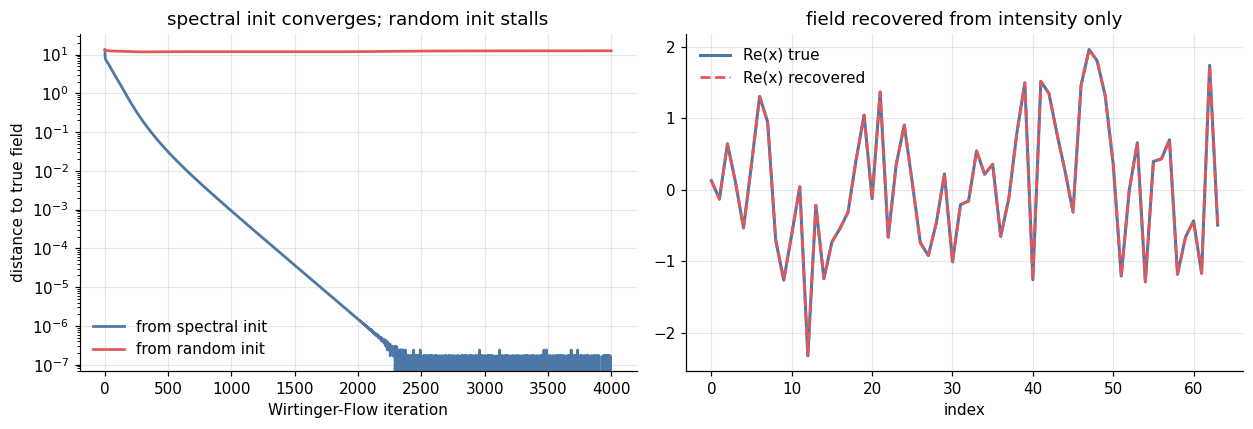

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4))
ax[0].semilogy(h_spec, color="#4C78A8", label="from spectral init")
ax[0].semilogy(h_rand, color="#E45756", label="from random init")
ax[0].set_xlabel("Wirtinger-Flow iteration"); ax[0].set_ylabel("distance to true field")
ax[0].set_title("spectral init converges; random init stalls"); ax[0].legend()
zc = z_spec*np.exp(1j*np.angle(np.vdot(z_spec, x_true)))    # align global phase
ax[1].plot(x_true.real, color="#4C78A8", lw=2, label="Re(x) true")
ax[1].plot(zc.real, "--", color="#E45756", label="Re(x) recovered")
ax[1].set_xlabel("index"); ax[1].set_title("field recovered from intensity only"); ax[1].legend()
plt.tight_layout(); plt.show()

## Connecting to the dispersion instrument

Spectral initialization *requires incoherent* measurements -- the eigenvector argument relies on the
sensing vectors being random-like. Dispersion alone, $A_D=\mathcal F^{-1}e^{\,j\pi Df^2}\mathcal F$, is
a **unitary, coherent** operator: its rows are not incoherent, so the plain spectral estimate does not
align with $x$ (verified separately), and the Gerchberg-Saxton projections remain the better solver
for pure dispersion diversity. To bring spectral initialization -- and its global-convergence
guarantee -- to the instrument, add **random coded masks** (multiply by random phase screens before
dispersing, i.e. coded diffraction patterns). That makes the effective sensing incoherent, and the
spectral-init + Wirtinger-Flow pipeline shown here applies directly. This is the design lesson: choose
the measurement so the reconstruction is well-posed.

## Summary

- Gradient descent on the phase-retrieval loss is non-convex; from a random start it can fail.
  **Spectral initialization** starts from the leading eigenvector of $Y=\tfrac1m\sum y_i a_ia_i^H$,
  which sits in the correct basin because $\mathbb E[Y]=\lVert x\rVert^2I+xx^H$ has top eigenvector $x$.
- **Wirtinger Flow** = spectral init + gradient descent recovers the field exactly at $m\approx4N$,
  while the same descent from a random start stalls in a spurious minimum.
- The method needs **incoherent** measurements; pure dispersion is coherent (use GS), but adding
  **random coded masks** makes spectral init + WF applicable to the dispersion instrument.

Subject-verb-object: the measurements build the data matrix; the eigenvector estimates the field;
Wirtinger Flow descends to the truth; incoherent sensing makes it global. This completes the
phase-recovery trilogy -- projections (GS), gradient descent, and spectral-initialized gradient flow.